## 1. Data Understanding

### Objective
Understand the structure, relationships, data types, missing values, and temporal information across the OULAD datasets before cleaning or feature engineering.

### Business Question
Can we identify students at risk of failing or withdrawing early enough for advisors to intervene?

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

RANDOM_STATE = 42

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "raw"

print("Data directory:", DATA_DIR.resolve())

Data directory: D:\Early Risk Detection for Student Success - OULAD\data\raw


In [2]:
student_info = pd.read_csv(DATA_DIR / "studentInfo.csv")
student_registration = pd.read_csv(DATA_DIR / "studentRegistration.csv")
courses = pd.read_csv(DATA_DIR / "courses.csv")
assessments = pd.read_csv(DATA_DIR / "assessments.csv")
student_assessment = pd.read_csv(DATA_DIR / "studentAssessment.csv")
student_vle = pd.read_csv(DATA_DIR / "studentVle.csv")
vle = pd.read_csv(DATA_DIR / "vle.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [3]:
datasets = {
    "student_info": student_info,
    "student_registration": student_registration,
    "courses": courses,
    "assessments": assessments,
    "student_assessment": student_assessment,
    "student_vle": student_vle,
    "vle": vle,
}

summary = pd.DataFrame({
    "rows": {name: df.shape[0] for name, df in datasets.items()},
    "columns": {name: df.shape[1] for name, df in datasets.items()},
})

summary

,rows,columns
student_info,32593,12
student_registration,32593,5
courses,22,3
assessments,206,6
student_assessment,173912,5
student_vle,10655280,6
vle,6364,6


In [4]:
for name, df in datasets.items():
    print(f"\n{'=' * 80}")
    print(name)
    print(f"Shape: {df.shape}")
    print(df.dtypes)


student_info
Shape: (32593, 12)
code_module             object
code_presentation       object
id_student               int64
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts     int64
studied_credits          int64
disability              object
final_result            object
dtype: object

student_registration
Shape: (32593, 5)
code_module             object
code_presentation       object
id_student               int64
date_registration      float64
date_unregistration    float64
dtype: object

courses
Shape: (22, 3)
code_module                   object
code_presentation             object
module_presentation_length     int64
dtype: object

assessments
Shape: (206, 6)
code_module           object
code_presentation     object
id_assessment          int64
assessment_type       object
date                 float64
weight               float64
dtype: object

stude

In [5]:
missing_summary = []

for name, df in datasets.items():
    missing = df.isna().sum()
    missing = missing[missing > 0]

    for column, count in missing.items():
        missing_summary.append({
            "dataset": name,
            "column": column,
            "missing_count": count,
            "missing_pct": round(count / len(df) * 100, 2)
        })

missing_summary = pd.DataFrame(missing_summary)

missing_summary.sort_values(
    ["dataset", "missing_pct"],
    ascending=[True, False]
)

,dataset,column,missing_count,missing_pct
3,assessments,date,11,5.34
4,student_assessment,score,173,0.10
0,student_info,imd_band,1111,3.41
2,student_registration,date_unregistration,22521,69.10
1,student_registration,date_registration,45,0.14
5,vle,week_from,5243,82.39
6,vle,week_to,5243,82.39


In [6]:
student_info["final_result"].value_counts(dropna=False)

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

In [7]:
student_info["final_result"].value_counts(normalize=True).mul(100).round(2)

final_result
Pass           37.93
Withdrawn      31.16
Fail           21.64
Distinction     9.28
Name: proportion, dtype: float64

## 2. Data Relationships and Key Validation

Before combining the datasets, we validate the keys used to connect students, courses, assessments, and VLE activity. This prevents incorrect joins and unintended row duplication.

In [8]:
print("student_info duplicate rows:",
      student_info.duplicated().sum())

print("student_registration duplicate rows:",
      student_registration.duplicated().sum())

print("courses duplicate rows:",
      courses.duplicated().sum())

print("assessments duplicate rows:",
      assessments.duplicated().sum())

print("student_assessment duplicate rows:",
      student_assessment.duplicated().sum())

print("student_vle duplicate rows:",
      student_vle.duplicated().sum())

print("vle duplicate rows:",
      vle.duplicated().sum())

student_info duplicate rows: 0
student_registration duplicate rows: 0
courses duplicate rows: 0
assessments duplicate rows: 0
student_assessment duplicate rows: 0
student_vle duplicate rows: 787170
vle duplicate rows: 0


In [9]:
print("student_info unique student-module-presentation:",
      student_info[
          ["code_module", "code_presentation", "id_student"]
      ].duplicated().sum())

print("student_registration unique student-module-presentation:",
      student_registration[
          ["code_module", "code_presentation", "id_student"]
      ].duplicated().sum())

print("assessments unique assessment ID:",
      assessments["id_assessment"].duplicated().sum())

print("student_assessment unique student-assessment pair:",
      student_assessment[
          ["id_student", "id_assessment"]
      ].duplicated().sum())

print("vle unique site-module-presentation:",
      vle[
          ["id_site", "code_module", "code_presentation"]
      ].duplicated().sum())

student_info unique student-module-presentation: 0
student_registration unique student-module-presentation: 0
assessments unique assessment ID: 0
student_assessment unique student-assessment pair: 0
vle unique site-module-presentation: 0


In [10]:
student_vle[student_vle.duplicated(keep=False)].head(20)

,code_module,code_presentation,id_student,id_site,date,sum_click
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
62,AAA,2013J,45462,546652,-10,1
63,AAA,2013J,45462,546652,-10,1
178,AAA,2013J,77367,546652,-10,4
180,AAA,2013J,77367,546652,-10,4
191,AAA,2013J,94961,546652,-10,2
193,AAA,2013J,94961,546652,-10,2
432,AAA,2013J,248270,546652,-10,4
442,AAA,2013J,248270,546652,-10,4


In [11]:
student_vle[
    student_vle.duplicated(keep=False)
].sort_values(
    ["id_student", "id_site", "date"]
).head(20)

,code_module,code_presentation,id_student,id_site,date,sum_click
211469,AAA,2014J,6516,877012,13,3
211472,AAA,2014J,6516,877012,13,3
219388,AAA,2014J,6516,877012,19,1
219392,AAA,2014J,6516,877012,19,1
222229,AAA,2014J,6516,877012,22,3
222230,AAA,2014J,6516,877012,22,3
237148,AAA,2014J,6516,877012,41,1
237150,AAA,2014J,6516,877012,41,1
243855,AAA,2014J,6516,877012,49,1
243858,AAA,2014J,6516,877012,49,1


In [12]:
student_vle_clean = student_vle.copy()

before = len(student_vle_clean)

student_vle_clean = student_vle_clean.drop_duplicates().copy()

after = len(student_vle_clean)

print(f"Rows before: {before:,}")
print(f"Rows after : {after:,}")
print(f"Removed    : {before - after:,}")
print(f"Removed %  : {(before - after) / before * 100:.2f}%")

Rows before: 10,655,280
Rows after : 9,868,110
Removed    : 787,170
Removed %  : 7.39%


In [13]:
print("Remaining exact duplicates:",
      student_vle_clean.duplicated().sum())

Remaining exact duplicates: 0


### Insight

All datasets contain no exact duplicate rows except `studentVle`, which contains 787,170 exact duplicate records (7.39% of its rows). After removing these duplicates, no exact duplicates remain. The duplicate issue is therefore isolated to the VLE activity table and is handled before further analysis.

## 3. Foreign Key Validation

Validate that identifiers used to connect the datasets exist in their corresponding reference tables before merging.

In [14]:
# Student IDs referenced by studentVle should exist in studentInfo
vle_student_ids = set(student_vle_clean["id_student"].unique())
info_student_ids = set(student_info["id_student"].unique())

missing_students_in_vle = vle_student_ids - info_student_ids

print("Student IDs in studentVle not found in studentInfo:",
      len(missing_students_in_vle))


# Assessment IDs referenced by studentAssessment should exist in assessments
student_assessment_ids = set(student_assessment["id_assessment"].unique())
assessment_ids = set(assessments["id_assessment"].unique())

missing_assessments = student_assessment_ids - assessment_ids

print("Assessment IDs in studentAssessment not found in assessments:",
      len(missing_assessments))


# Site IDs referenced by studentVle should exist in vle
student_vle_sites = set(student_vle_clean["id_site"].unique())
vle_sites = set(vle["id_site"].unique())

missing_sites = student_vle_sites - vle_sites

print("Site IDs in studentVle not found in vle:",
      len(missing_sites))

Student IDs in studentVle not found in studentInfo: 0
Assessment IDs in studentAssessment not found in assessments: 0
Site IDs in studentVle not found in vle: 0


### Insight

All checked foreign-key relationships are valid: student IDs in `studentVle` exist in `studentInfo`, assessment IDs in `studentAssessment` exist in `assessments`, and site IDs in `studentVle` exist in `vle`. This indicates that the main datasets can be linked without unmatched keys.

## 4. Data Granularity

Each dataset records information at a different level of detail. We inspect the number of unique students, courses, assessments, and activity records before designing the integration strategy.

In [15]:
print("studentInfo")
print("Rows:", len(student_info))
print("Unique students:", student_info["id_student"].nunique())
print("Unique module-presentation pairs:",
      student_info[["code_module", "code_presentation"]].drop_duplicates().shape[0])

studentInfo
Rows: 32593
Unique students: 28785
Unique module-presentation pairs: 22


In [16]:
print("studentRegistration")
print("Rows:", len(student_registration))
print("Unique students:", student_registration["id_student"].nunique())
print("Unique student-module-presentation:",
      student_registration[
          ["code_module", "code_presentation", "id_student"]
      ].drop_duplicates().shape[0])

studentRegistration
Rows: 32593
Unique students: 28785
Unique student-module-presentation: 32593


In [17]:
print("assessments")
print("Rows:", len(assessments))
print("Unique assessments:", assessments["id_assessment"].nunique())
print("Unique module-presentations:",
      assessments[
          ["code_module", "code_presentation"]
      ].drop_duplicates().shape[0])

assessments
Rows: 206
Unique assessments: 206
Unique module-presentations: 22


In [18]:
print("studentAssessment")
print("Rows:", len(student_assessment))
print("Unique students:",
      student_assessment["id_student"].nunique())
print("Unique assessments:",
      student_assessment["id_assessment"].nunique())
print("Unique student-assessment pairs:",
      student_assessment[
          ["id_student", "id_assessment"]
      ].drop_duplicates().shape[0])

studentAssessment
Rows: 173912
Unique students: 23369
Unique assessments: 188
Unique student-assessment pairs: 173912


In [19]:
print("vle")
print("Rows:", len(vle))
print("Unique sites:", vle["id_site"].nunique())
print("Unique module-presentations:",
      vle[
          ["code_module", "code_presentation"]
      ].drop_duplicates().shape[0])

vle
Rows: 6364
Unique sites: 6364
Unique module-presentations: 22


In [20]:
print("studentVle")
print("Rows after exact-duplicate removal:", len(student_vle_clean))
print("Unique students:",
      student_vle_clean["id_student"].nunique())
print("Unique sites:",
      student_vle_clean["id_site"].nunique())
print("Unique student-site-date combinations:",
      student_vle_clean[
          ["id_student", "id_site", "date"]
      ].drop_duplicates().shape[0])

studentVle
Rows after exact-duplicate removal: 9868110
Unique students: 26074
Unique sites: 6268
Unique student-site-date combinations: 8459320


### Insight

The OULAD tables operate at different levels of granularity. `studentInfo` contains student-level information, `studentRegistration` describes student-module registrations, `assessments` defines assessment-level information, `studentAssessment` records student-assessment outcomes, and `studentVle` captures detailed daily student activity. Understanding these levels is essential before combining the datasets to avoid incorrect joins and unintended row multiplication.

## 5. Temporal Structure

The prediction task must respect the information available at each point in time. We inspect the date and week variables used across assessments, registration, and VLE activity before defining the early-warning prediction windows.

In [21]:
print("Assessment date range:")
print(assessments["date"].min(), "to", assessments["date"].max())

print("\nStudent VLE date range:")
print(student_vle_clean["date"].min(), "to", student_vle_clean["date"].max())

print("\nRegistration date range:")
print(student_registration["date_registration"].min(),
      "to",
      student_registration["date_registration"].max())

Assessment date range:
12.0 to 261.0

Student VLE date range:
-25 to 269

Registration date range:
-322.0 to 167.0


In [22]:
print("Assessment dates missing:",
      assessments["date"].isna().sum())

print("Unique VLE dates:",
      student_vle_clean["date"].nunique())

print("VLE date values:")
print(
    student_vle_clean["date"]
    .sort_values()
    .unique()[:20]
)

Assessment dates missing: 11
Unique VLE dates: 295
VLE date values:
[-25 -24 -23 -22 -21 -20 -19 -18 -17 -16 -15 -14 -13 -12 -11 -10  -9  -8
  -7  -6]


### Insight

The datasets use relative time references to describe activity throughout a course. Assessment dates contain 11 missing values, while VLE activity spans from day -25 to day 269 and registration dates span from day -322 to day 167. The presence of pre-course and post-course relative dates highlights the need to respect the timing of information when constructing an early-risk prediction dataset.

## 6. Course Timeline and Weekly Structure

The OULAD data uses relative days from the start of a course presentation. We inspect the VLE week metadata and the distribution of activity over time before defining prediction windows.

In [23]:
print("VLE week_from / week_to:")
print(
    vle[["week_from", "week_to"]]
    .describe()
)

print("\nMissing week metadata:")
print(
    vle[["week_from", "week_to"]]
    .isna()
    .sum()
)

VLE week_from / week_to:
         week_from      week_to
count  1121.000000  1121.000000
mean     15.204282    15.214987
std       8.792865     8.779806
min       0.000000     0.000000
25%       8.000000     8.000000
50%      15.000000    15.000000
75%      22.000000    22.000000
max      29.000000    29.000000

Missing week metadata:
week_from    5243
week_to      5243
dtype: int64


In [24]:
print("Unique week_from values:")
print(
    sorted(vle["week_from"].dropna().unique())
)

print("\nUnique week_to values:")
print(
    sorted(vle["week_to"].dropna().unique())
)

Unique week_from values:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0)]

Unique week_to values:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0

In [25]:
activity_by_day = (
    student_vle_clean
    .groupby("date", as_index=False)
    .agg(
        total_clicks=("sum_click", "sum"),
        active_records=("id_student", "size"),
        unique_students=("id_student", "nunique")
    )
    .sort_values("date")
)

activity_by_day.head(15)

,date,total_clicks,active_records,unique_students
0,-25,13666,4096,554
1,-24,14262,3724,551
2,-23,9042,2482,457
3,-22,5448,1636,334
4,-21,3382,1222,274
5,-20,4356,1535,306
6,-19,5236,1632,348
7,-18,172030,56196,5432
8,-17,91052,31211,4278
9,-16,84720,29933,4242


In [26]:
activity_by_day.tail(15)

,date,total_clicks,active_records,unique_students
280,255,4951,2487,1131
281,256,4539,2374,1081
282,257,3909,1958,980
283,258,3280,1727,905
284,259,2052,1087,579
285,260,2583,1476,711
286,261,4390,2296,1140
287,262,3741,1895,909
288,263,2948,1385,695
289,264,3092,1407,687


In [27]:
vle[
    ["id_site", "activity_type", "week_from", "week_to"]
].dropna(
    subset=["week_from", "week_to"]
).sort_values(
    ["week_from", "week_to"]
).head(20)

,id_site,activity_type,week_from,week_to
3270,773452,url,0.0,0.0
3647,813933,oucontent,0.0,0.0
198,546719,oucontent,1.0,1.0
210,546681,oucontent,1.0,1.0
323,877045,oucontent,1.0,1.0
391,877044,oucontent,1.0,1.0
777,704071,resource,1.0,1.0
889,703900,oucontent,1.0,1.0
938,704217,resource,1.0,1.0
969,703943,subpage,1.0,1.0


In [28]:
vle[
    ["week_from", "week_to"]
].dropna().value_counts().sort_index().head(30)

week_from  week_to
0.0        0.0         2
1.0        1.0        80
           2.0         4
2.0        2.0        41
3.0        3.0        33
           4.0         2
4.0        4.0        24
5.0        5.0        31
           7.0         2
6.0        6.0        17
7.0        7.0        15
8.0        8.0        34
           9.0         2
9.0        9.0        52
10.0       10.0       40
11.0       11.0       47
12.0       12.0       26
13.0       13.0       31
14.0       14.0       32
15.0       15.0       46
16.0       16.0       27
17.0       17.0        4
18.0       18.0       91
19.0       19.0       29
20.0       20.0       43
21.0       21.0       51
22.0       22.0       38
23.0       23.0       33
24.0       24.0       33
25.0       25.0       24
Name: count, dtype: int64

In [29]:
week_check = vle.dropna(
    subset=["week_from", "week_to"]
).copy()

print(
    "Rows where week_to < week_from:",
    (week_check["week_to"] < week_check["week_from"]).sum()
)

print(
    "Minimum week_from:",
    week_check["week_from"].min()
)

print(
    "Maximum week_to:",
    week_check["week_to"].max()
)

Rows where week_to < week_from: 0
Minimum week_from: 0.0
Maximum week_to: 29.0


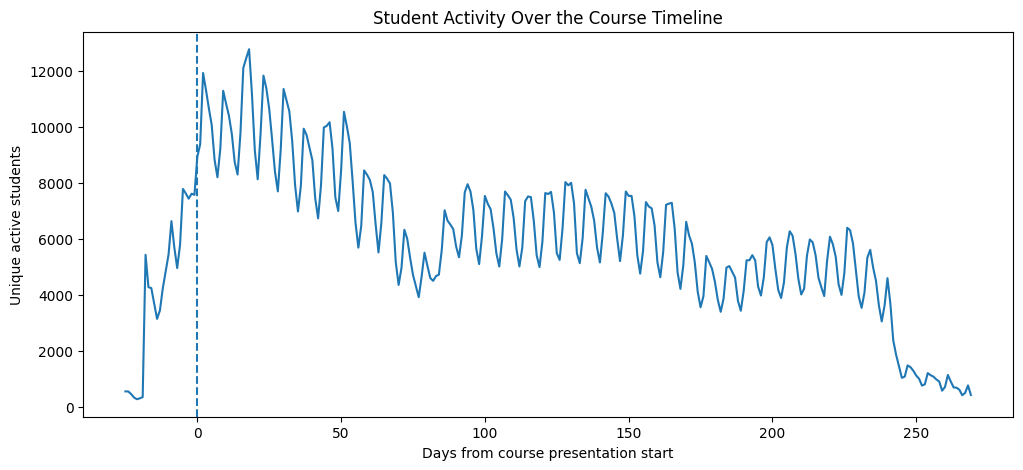

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(
    activity_by_day["date"],
    activity_by_day["unique_students"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Days from course presentation start")
plt.ylabel("Unique active students")
plt.title("Student Activity Over the Course Timeline")

plt.show()

### Insight

Student activity changes substantially across the course timeline. Activity rises sharply around the course start, remains at a higher level during the main teaching period with clear fluctuations, and declines toward the end of the course. This confirms that student engagement is strongly dependent on course timing and supports using time-aware features when building the early-risk model.

In [31]:
student_registration["date_unregistration"]

0          NaN
1          NaN
2         12.0
3          NaN
4          NaN
         ...  
32588      NaN
32589      NaN
32590      NaN
32591    101.0
32592      NaN
Name: date_unregistration, Length: 32593, dtype: float64

In [32]:
pd.crosstab(
    student_info["final_result"],
    student_registration["date_unregistration"].isna(),
    margins=True
)

date_unregistration,False,True,All
final_result,,,
Distinction,0,3024,3024
Fail,9,7043,7052
Pass,0,12361,12361
Withdrawn,10063,93,10156
All,10072,22521,32593


In [33]:
pd.crosstab(
    student_registration["date_unregistration"].isna(),
    student_info["final_result"],
    normalize="index"
).round(3)

final_result,Distinction,Fail,Pass,Withdrawn
date_unregistration,,,,
False,0.000,0.001,0.000,0.999
True,0.134,0.313,0.549,0.004


### Insight

Missing `date_unregistration` is strongly associated with students who did not withdraw. However, a small number of withdrawn students also have a missing unregistration date. Therefore, a missing withdrawal date should not be treated as a perfect proxy for the final outcome.

## 7. Missing Value Investigation

Missing values are investigated according to the meaning of each variable and its relationship to the final outcome. We do not apply a single missing-value treatment to all columns.

In [34]:
student_info["imd_band"].value_counts(dropna=False)

imd_band
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
NaN        1111
Name: count, dtype: int64

In [35]:
pd.crosstab(
    student_info["imd_band"].isna(),
    student_info["final_result"],
    normalize="index"
).round(3)

final_result,Distinction,Fail,Pass,Withdrawn
imd_band,,,,
False,0.090,0.219,0.376,0.315
True,0.179,0.131,0.478,0.212


### Insight

`imd_band` has 1,111 missing values (3.41%). The outcome distribution differs between students with and without an IMD band value, indicating that the missingness may carry information rather than being purely random. The variable should therefore be handled deliberately during feature preparation rather than blindly dropping these records.

In [36]:
print(student_assessment["score"].isna().sum())

173


In [37]:
student_assessment.loc[
    student_assessment["score"].isna(),
    "id_assessment"
].value_counts()

id_assessment
25339    7
15013    7
34860    6
25363    5
14984    5
14998    5
15012    4
34888    4
15020    4
25334    3
14989    3
14986    3
25356    3
25336    3
34864    3
34874    3
34877    3
34902    3
34900    3
34873    3
15022    3
15010    3
34863    3
34890    3
24291    3
14987    2
14988    2
25366    2
25367    2
14999    2
37435    2
34899    2
34876    2
34889    2
25364    2
25348    2
25349    2
25353    2
25360    2
25350    2
25357    2
24282    2
24292    2
24285    2
15024    2
15011    2
25335    2
25338    2
30712    2
25359    2
1754     1
1752     1
1760     1
14985    1
15001    1
15000    1
14997    1
25337    1
15021    1
15008    1
24284    1
24293    1
25358    1
25355    1
30722    1
34861    1
25365    1
30710    1
30714    1
30715    1
34862    1
30719    1
34875    1
34887    1
34886    1
34903    1
37415    1
37427    1
Name: count, dtype: int64

In [38]:
student_assessment.loc[
    student_assessment["score"].isna()
].head(20)

,id_assessment,id_student,date_submitted,is_banked,score
215,1752,721259,22,0,NaN
937,1754,260355,127,0,NaN
2364,1760,2606802,180,0,NaN
3358,14984,186780,77,0,NaN
3914,14984,531205,26,0,NaN
3943,14984,534151,7,0,NaN
4206,14984,549713,84,0,NaN
4311,14984,554393,55,0,NaN
4753,14985,186780,77,0,NaN
5722,14986,33666,117,0,NaN


In [39]:
student_assessment.loc[
    student_assessment["score"].isna(),
    "is_banked"
].value_counts(dropna=False)

is_banked
0    172
1      1
Name: count, dtype: int64

In [40]:
student_assessment.loc[
    student_assessment["score"].isna(),
    "date_submitted"
].value_counts(dropna=False).sort_index()

date_submitted
-2      1
-1      1
 7      1
 11     1
 13     1
       ..
 237    2
 241    3
 258    1
 270    1
 274    1
Name: count, Length: 117, dtype: int64

### Insight

Only 173 student-assessment records have a missing `score`. These missing scores occur across multiple assessments and are not explained simply by the absence of a submission date. Therefore, missing scores should not automatically be interpreted as failed or unsubmitted assessments; their treatment should be decided during feature engineering based on the meaning of the assessment data.

In [41]:
assessments.loc[assessments["date"].isna()]

,code_module,code_presentation,id_assessment,assessment_type,date,weight
5,AAA,2013J,1757,Exam,NaN,100.0
11,AAA,2014J,1763,Exam,NaN,100.0
23,BBB,2013B,14990,Exam,NaN,100.0
35,BBB,2013J,15002,Exam,NaN,100.0
47,BBB,2014B,15014,Exam,NaN,100.0
53,BBB,2014J,15025,Exam,NaN,100.0
62,CCC,2014B,24290,Exam,NaN,100.0
63,CCC,2014B,40087,Exam,NaN,100.0
72,CCC,2014J,24299,Exam,NaN,100.0
73,CCC,2014J,40088,Exam,NaN,100.0


In [42]:
assessments.loc[
    assessments["date"].isna(),
    "id_assessment"
].isin(
    student_assessment["id_assessment"]
).value_counts()

id_assessment
False    8
True     3
Name: count, dtype: int64

In [43]:
missing_assessment_ids = assessments.loc[
    assessments["date"].isna(),
    "id_assessment"
]

student_assessment[
    student_assessment["id_assessment"].isin(missing_assessment_ids)
]["id_assessment"].value_counts()

id_assessment
24299    1168
25368     950
24290     747
Name: count, dtype: int64

In [44]:
assessments[
    assessments["id_assessment"].isin([24299, 25368, 24290])
]

,code_module,code_presentation,id_assessment,assessment_type,date,weight
62,CCC,2014B,24290,Exam,NaN,100.0
72,CCC,2014J,24299,Exam,NaN,100.0
108,DDD,2014J,25368,Exam,NaN,100.0


## Insight
11 assessments have missing dates; 8 are unused in studentAssessment, while 3 are linked to 2,865 student-assessment records. These three assessments require special attention because their missing timestamps create temporal uncertainty for early-risk feature construction.

## Data Understanding Summary

The OULAD data was reviewed across structure, relationships, granularity,
temporal coverage, and missingness before cleaning and feature engineering.

### Key findings

- `studentVle` contains **787,170 exact duplicate rows (7.39%)**; these are
  removed in Notebook 02 before downstream analysis.
- The main student-course and assessment relationships were validated, with
  **no unmatched foreign keys** found in the relationship checks.
- The datasets have different granularities, so direct many-to-many joins
  can multiply rows. The project therefore uses a student-course level base
  table for feature engineering.
- The data has a clear temporal structure through relative course-day
  variables, registration timing, assessment dates, and VLE activity dates.
- Missing `date_unregistration` is strongly associated with final outcome
  status, but it is not treated as a direct predictor because it contains
  future information.
- Missing `imd_band` is preserved as an `Unknown` category during cleaning
  rather than dropping those student records.
- Missing assessment scores are preserved as missing information and are not
  automatically interpreted as failed assessments.
- **11 assessment dates are missing**; 8 of those assessments are unused in
  `studentAssessment`, while 3 are linked to **2,865 student-assessment
  records**. These timestamps require care when constructing early-warning
  features.

### Transition to the next stage

The data-understanding stage establishes the data structure and the main
quality and temporal considerations needed for safe cleaning and
leakage-aware feature engineering. Notebook 02 can therefore proceed with
duplicate removal, type standardization, and explicit missingness handling.
